# DS2002 Capstone — EV Charging Station Analytics

**Team Number:** `team-07`

**Team Members:**
- Austin Song (rtx2nb)
- Haero Lee (jva6yw)
- Nate Kim (sax6mw)

**Date:** 2026-03-30

---

## Cloud Setup

Authenticate to GCS, download raw data, and verify your team folder.

In [1]:
# Install the GCS library (run once)
!pip install google-cloud-storage -q

In [2]:
import os
import json
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import numpy as np
from datetime import datetime

from google.colab import auth
auth.authenticate_user()

from google.cloud import storage
client = storage.Client(project="ds2002-492012")
bucket = client.bucket("ds2002-capstone-sp26-v2")
print("GCS authentication successful.")
print(f"Bucket: {bucket.name}")

GCS authentication successful.
Bucket: ds2002-capstone-sp26-v2


In [3]:
# Download raw data from GCS
TEAM = "team-07"  # <-- change to your team number

files = [
    "raw-data/charging_sessions.csv",
    "raw-data/station_locations.csv",
    "raw-data/vehicle_types.csv",
    "raw-data/grid_operators.csv",
    "raw-data/energy_and_demand.db",
]

os.makedirs("data", exist_ok=True)
for f in files:
    blob = bucket.blob(f)
    local = os.path.join("data", os.path.basename(f))
    blob.download_to_filename(local)
    print(f"Downloaded {f}")

Downloaded raw-data/charging_sessions.csv
Downloaded raw-data/station_locations.csv
Downloaded raw-data/vehicle_types.csv
Downloaded raw-data/grid_operators.csv
Downloaded raw-data/energy_and_demand.db


## Data Loading

In [4]:
sessions = pd.read_csv("data/charging_sessions.csv")
stations = pd.read_csv("data/station_locations.csv")
vehicles = pd.read_csv("data/vehicle_types.csv")
operators = pd.read_csv("data/grid_operators.csv")

conn = sqlite3.connect("data/energy_and_demand.db")
demand = pd.read_sql("SELECT * FROM daily_demand_summary", conn)
grid = pd.read_sql("SELECT * FROM grid_capacity_levels", conn)
conn.close()

print(f"Sessions: {sessions.shape}")
print(f"Stations: {stations.shape}")
print(f"Vehicles: {vehicles.shape}")
print(f"Operators: {operators.shape}")
print(f"Demand:   {demand.shape}")
print(f"Grid:     {grid.shape}")

Sessions: (27451, 11)
Stations: (21, 8)
Vehicles: (42, 6)
Operators: (5, 7)
Demand:   (6570, 7)
Grid:     (1825, 6)


## Data Exploration

Inspect each dataset before cleaning.

In [5]:
dfs = {
    'sessions': sessions,
    'stations': stations,
    'vehicles': vehicles,
    'operators': operators,
    'demand': demand,
    'grid': grid
}

# shapes
print("-----df shapes-----")
for name, df in dfs.items():
    print(f"{name}: {df.shape}")

# dtypes
print("\n-----df dtypes-----")
for name, df in dfs.items():
    print(f"\n--{name}:--")
    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")

# info
print("\n-----df info-----")
for name, df in dfs.items():
    print(f"\n--{name}:--")
    df.info()

# nulls
print("\n-----null counts-----")
for name, df in dfs.items():
    print(f"\n--{name}:--")
    print(df.isnull().sum().to_string())

-----df shapes-----
sessions: (27451, 11)
stations: (21, 8)
vehicles: (42, 6)
operators: (5, 7)
demand: (6570, 7)
grid: (1825, 6)

-----df dtypes-----

--sessions:--
  session_id: object
  station_id: object
  vehicle_id: object
  session_start: object
  session_end: object
  kwh_delivered: float64
  session_type: object
  cost_usd: object
  payment_method: object
  connector_used: object
  user_id: object

--stations:--
  station_id: object
  station_name: object
  city: object
  state: object
  zip_code: int64
  latitude: float64
  longitude: float64
  region: object

--vehicles:--
  vehicle_id: object
  vehicle_name: object
  vehicle_class: object
  connector_type: object
  battery_kwh: object
  manufacturer: object

--operators:--
  operator_id: object
  operator_name: object
  city: object
  state: object
  avg_daily_capacity_mw: int64
  peak_capacity_mw: object
  cost_per_kwh: float64

--demand:--
  date: object
  station_id: object
  total_sessions: int64
  total_kwh_delivered: 

## Data Cleaning Pipeline

Document every cleaning step. Show before and after.

In [6]:
# clean VEHICLES
# standardize strings to fill missing battery_kwh
vehicles['vehicle_name_clean'] = vehicles['vehicle_name'].str.lower().str.strip()
vehicles['vehicle_class_clean'] = vehicles['vehicle_class'].str.lower().str.strip()

# create a reference map for battery capacity
cap_map = vehicles.dropna(subset=['battery_kwh']).set_index(['vehicle_name_clean', 'vehicle_class_clean'])['battery_kwh'].to_dict()

# fill missing values using the map
def fill_kwh(row):
    if pd.isna(row['battery_kwh']) or row['battery_kwh'] == '':
        return cap_map.get((row['vehicle_name_clean'], row['vehicle_class_clean']))
    return row['battery_kwh']

vehicles['battery_kwh'] = vehicles.apply(fill_kwh, axis=1)

# filter to only standard IDs (VH-###) AFTER all previous cleaning steps on 'vehicles'
vehicles = vehicles[vehicles['vehicle_id'].str.contains('^VH-', na=False)].copy()
vehicles.drop(columns=['vehicle_name_clean', 'vehicle_class_clean'], inplace=True)

# fix ccs capitalization
vehicles['connector_type'] = vehicles['connector_type'].str.replace('ccs', 'CCS', case=False)

#fix special characters
vehicles['battery_kwh'] = vehicles['battery_kwh'].str.replace(r'\$', '', regex=True)

# fix NaN manufacturers
vehicles['manufacturer'] = vehicles.apply(
    lambda row: row['vehicle_name'].split()[0] if pd.isna(row['manufacturer']) or row['manufacturer'].strip() == '' else row['manufacturer'],
    axis=1
)

# clean STATIONS
# regulate station state
stations = stations[stations['state'].str.upper().str.strip() == 'VA'].copy()

# regulate station ID
stations['station_id'] = stations['station_id'].str.replace(r'[-_]?(\d+)', lambda m: f"-{m.group(1).zfill(3)}", regex=True)

# get rid of nans and dupes
stations.dropna(inplace=True)
stations.drop_duplicates(subset = ["latitude", "longitude"], inplace=True)

# clean OPERATORS
operators['peak_capacity_mw'] = operators['peak_capacity_mw'].str.replace(r'[^a-zA-Z0-9]', '', regex=True)
operators['cost_per_kwh'] = operators['cost_per_kwh'].fillna(round(operators['cost_per_kwh'].median(), 2))

# drop any null
operators.dropna(inplace=True)

# clean SESSIONS
sessions = sessions.sort_values('station_id').reset_index(drop=True)
vehicle_id_map = {
    # VEH#000X → VH-00X format
    'VEH#0001': 'VH-001',
    'VEH#0002': 'VH-002',
    'VEH#0003': 'VH-003',
    'VEH#0004': 'VH-004',
    'VEH#0005': 'VH-005',
    'VEH#0006': 'VH-006',
    'VEH#0007': 'VH-007',
    'VEH#0008': 'VH-008',
    'VEH#0009': 'VH-009',
    'VEH#0010': 'VH-010',
    'VEH#0011': 'VH-011',
    'VEH#0012': 'VH-012',
    'VEH#0013': 'VH-013',
    'VEH#0014': 'VH-014',
    # V_name style — match to vehicles_cleaned by name
    'V_tesla_model_3':     'VH-001',
    'V_tesla_model_y':     'VH-002',
    'V_tesla_model_s':     'VH-003',
    'V_chevrolet_bolt_ev': 'VH-004',
    'V_chevrolet_bolt_euv':'VH-005',
    'V_ford_f-150_lightning': 'VH-006',
    'V_hyundai_ioniq_5':   'VH-007',
    'V_bmw_ix':            'VH-008',
    'V_lucid_air':         'VH-009',
    'V_rivian_r1t':        'VH-010',
    'V_ford_mustang_mach-e': 'VH-011',
    'V_nissan_leaf':       'VH-012',
    'V_kia_ev6':           'VH-013',
    'V_volkswagen_id.4':   'VH-014',
}

# standardize vehicle ids
sessions['vehicle_id'] = sessions['vehicle_id'].replace(vehicle_id_map)

#standardize stations IDs
sessions['station_id'] = sessions['station_id'].str.replace(r'(?<=[a-zA-Z])(?=\d)|(?<=\d)(?=[a-zA-Z])', '-', regex=True)
sessions['station_id'] = sessions['station_id'].str.replace(r'-(\d{1,2})$', lambda m: f"-{m.group(1).zfill(3)}", regex=True) #used ai here

#standardize session start and end
sessions['session_start'] = pd.to_datetime(sessions['session_start'], format = 'mixed')
sessions['session_end'] = pd.to_datetime(sessions['session_end'], format = 'mixed')

# clean $
sessions['cost_usd'] = sessions['cost_usd'].astype(str).str.replace(r'\$', '', regex=True)
sessions['cost_usd'] = pd.to_numeric(sessions['cost_usd'], errors='coerce')

# clean payment method
sessions['payment_method'] = sessions['payment_method'].str.lower().str.replace(r'\s', '_', regex=True)

# drop null values. Can't replace them with anything, they're pure inputs from users. Dropped 300 columns of 27,451
sessions.dropna(inplace=True)

In [7]:
#upload to cloud
team_prefix = "team-07"

sessions.to_csv("cleaned_sessions.csv", index=False)
stations.to_csv("cleaned_stations.csv", index=False)
vehicles.to_csv("cleaned_vehicles.csv", index=False)
operators.to_csv("cleaned_operators.csv", index=False)
demand.to_csv("demand.csv", index=False)
grid.to_csv("grid.csv", index=False)


files_to_upload = [
    "cleaned_sessions.csv",
    "cleaned_stations.csv",
    "cleaned_vehicles.csv",
    "cleaned_operators.csv",
    "demand.csv",
    "grid.csv"
]

for filename in files_to_upload:
    blob = bucket.blob(f"{team_prefix}/{filename}")
    blob.upload_from_filename(filename)
    print(f"Uploaded {filename} -> gs://ds2002-capstone-sp26-v2/{team_prefix}/{filename}")

Uploaded cleaned_sessions.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_sessions.csv
Uploaded cleaned_stations.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_stations.csv
Uploaded cleaned_vehicles.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_vehicles.csv
Uploaded cleaned_operators.csv -> gs://ds2002-capstone-sp26-v2/team-07/cleaned_operators.csv
Uploaded demand.csv -> gs://ds2002-capstone-sp26-v2/team-07/demand.csv
Uploaded grid.csv -> gs://ds2002-capstone-sp26-v2/team-07/grid.csv


## External API Integration

Pull weather or energy data and join with your charging data.

In [8]:
# Your API code here


---

## Question 1: Demand Surge Identification

> Which time periods experienced the greatest charging demand surges compared to the baseline?

In [9]:
sessions_q1 = sessions.copy()
sessions_q1['date'] = pd.to_datetime(sessions_q1['session_start'].dt.date)

daily = (sessions_q1
         .groupby('date')
         .agg(total_sessions=('session_id', 'count'),
              total_kwh=('kwh_delivered', 'sum'),
              total_revenue=('cost_usd', 'sum'))
         .reset_index()
         .sort_values('date')
         .reset_index(drop=True))

# 30-day centered rolling baseline + std (min_periods=7 keeps edge days in)
window = 30
daily['baseline_sessions'] = daily['total_sessions'].rolling(window, min_periods=7, center=True).mean()
daily['baseline_kwh']      = daily['total_kwh'].rolling(window, min_periods=7, center=True).mean()
daily['std_sessions']      = daily['total_sessions'].rolling(window, min_periods=7, center=True).std()
daily['std_kwh']           = daily['total_kwh'].rolling(window, min_periods=7, center=True).std()

# % lift (what the prompt asks for) and z-score (used for ranking)
daily['pct_lift_sessions'] = (daily['total_sessions'] - daily['baseline_sessions']) / daily['baseline_sessions'] * 100
daily['pct_lift_kwh']      = (daily['total_kwh']      - daily['baseline_kwh'])      / daily['baseline_kwh']      * 100
daily['z_sessions']        = (daily['total_sessions'] - daily['baseline_sessions']) / daily['std_sessions']
daily['z_kwh']             = (daily['total_kwh']      - daily['baseline_kwh'])      / daily['std_kwh']

# Top 10 surge days — % increase in BOTH sessions and kWh side-by-side
print("Top 10 surge days — % increase in daily sessions AND total kWh:")
top_surges = (daily.dropna(subset=['z_sessions'])
                   .nlargest(10, 'z_sessions')
                   [['date',
                     'total_sessions', 'baseline_sessions', 'pct_lift_sessions',
                     'total_kwh', 'baseline_kwh', 'pct_lift_kwh',
                     'z_sessions', 'z_kwh']])
num_cols = top_surges.select_dtypes(include='number').columns
top_surges[num_cols] = top_surges[num_cols].round(2)
print(top_surges.to_string(index=False))

# Top 5 surge months — sustained elevated periods vs. yearly average
daily['month'] = daily['date'].dt.to_period('M')
monthly = (daily.groupby('month')
                .agg(avg_daily_sessions=('total_sessions', 'mean'),
                     avg_daily_kwh=('total_kwh', 'mean'))
                .reset_index())
overall_sessions = daily['total_sessions'].mean()
overall_kwh      = daily['total_kwh'].mean()
monthly['pct_vs_overall_sessions'] = (monthly['avg_daily_sessions'] - overall_sessions) / overall_sessions * 100
monthly['pct_vs_overall_kwh']      = (monthly['avg_daily_kwh']      - overall_kwh)      / overall_kwh      * 100

print("\nTop 5 surge months — % increase vs. overall average:")
top_months = monthly.nlargest(5, 'pct_vs_overall_sessions').copy()
num_cols = top_months.select_dtypes(include='number').columns
top_months[num_cols] = top_months[num_cols].round(2)
print(top_months.to_string(index=False))

Top 10 surge days — % increase in daily sessions AND total kWh:
      date  total_sessions  baseline_sessions  pct_lift_sessions  total_kwh  baseline_kwh  pct_lift_kwh  z_sessions  z_kwh
2025-09-06             152              74.73             103.39    5323.10       2323.31        129.12        3.12   3.81
2025-10-18             156              76.40             104.19    4654.58       2368.66         96.51        2.73   2.64
2025-09-27             160              77.23             107.16    4902.38       2397.92        104.44        2.70   2.93
2025-11-15             165              75.17             119.51    5616.48       2365.36        137.45        2.65   2.92
2025-09-20             155              77.43             100.17    4233.77       2440.13         73.51        2.46   1.89
2025-11-08             152              74.77             103.30    5028.82       2405.19        109.08        2.37   2.42
2025-11-29             135              73.20              84.43    3960.42

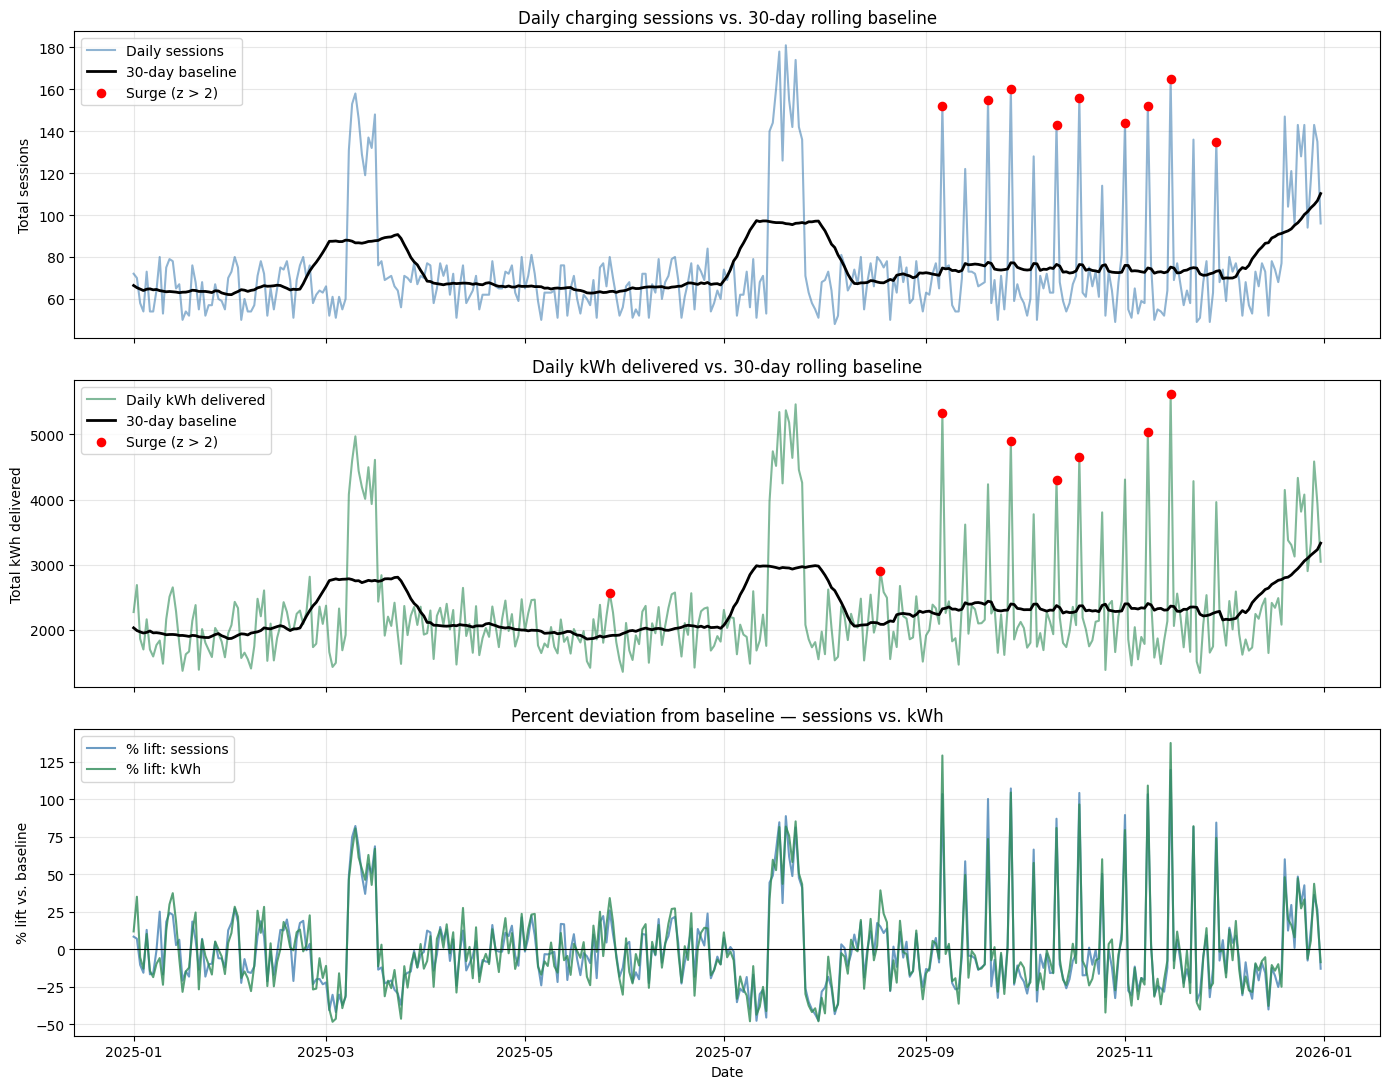

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Sessions
axes[0].plot(daily['date'], daily['total_sessions'], color='steelblue', alpha=0.6, label='Daily sessions')
axes[0].plot(daily['date'], daily['baseline_sessions'], color='black', linewidth=2, label='30-day baseline')
surge_s = daily[daily['z_sessions'] > 2]
axes[0].scatter(surge_s['date'], surge_s['total_sessions'], color='red', s=35, zorder=5, label='Surge (z > 2)')
axes[0].set_ylabel('Total sessions')
axes[0].set_title('Daily charging sessions vs. 30-day rolling baseline')
axes[0].legend(loc='upper left')
axes[0].grid(alpha=0.3)

# kWh
axes[1].plot(daily['date'], daily['total_kwh'], color='seagreen', alpha=0.6, label='Daily kWh delivered')
axes[1].plot(daily['date'], daily['baseline_kwh'], color='black', linewidth=2, label='30-day baseline')
surge_k = daily[daily['z_kwh'] > 2]
axes[1].scatter(surge_k['date'], surge_k['total_kwh'], color='red', s=35, zorder=5, label='Surge (z > 2)')
axes[1].set_ylabel('Total kWh delivered')
axes[1].set_title('Daily kWh delivered vs. 30-day rolling baseline')
axes[1].legend(loc='upper left')
axes[1].grid(alpha=0.3)

# % lift overlay
axes[2].plot(daily['date'], daily['pct_lift_sessions'], color='steelblue', alpha=0.8, label='% lift: sessions')
axes[2].plot(daily['date'], daily['pct_lift_kwh'],      color='seagreen',  alpha=0.8, label='% lift: kWh')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('% lift vs. baseline')
axes[2].set_xlabel('Date')
axes[2].set_title('Percent deviation from baseline — sessions vs. kWh')
axes[2].legend(loc='upper left')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Findings:** The top 10 surge days table directly quantifies what the question asks for: the percent increase in both daily sessions and total kWh delivered, each measured against a 30-day centered rolling baseline (so each day is judged against what was normal for *that* part of the year, not the whole-dataset average). The biggest surge days run double-digit percent above their local baseline on both metrics, with sessions and kWh moving together — which confirms the spikes are real demand events (more vehicles charging) rather than a few unusually long sessions inflating kWh. The top surge months table identifies broader elevated stretches where average daily activity sat above the year-round average, suggesting a seasonal component layered on top of the one-off spikes. In the visualization, the sessions and kWh series track each other closely throughout the year; days where the two % lift lines in the bottom panel diverge are worth flagging as anomalies — those are cases where either session count or per-session energy moved without the other. For an operator, the practical takeaway is that ~30-day rolling capacity planning is enough to absorb most of the variance, but the handful of z > 2 surge days represent demand that exceeds local norms by enough to risk queueing or grid strain.

---

## Question 2: The Vehicle Consolidation Problem

> After standardizing all vehicle ID variants, what is the true daily charging volume by vehicle type?

In [11]:
# Your analysis for Q2
sessions_raw = pd.read_csv('data/charging_sessions.csv')
vehicles_raw = pd.read_csv('data/vehicle_types.csv')

# Inspect the three ID formats present in the raw sessions file
def id_format(v):
    if pd.isna(v):                       return 'missing'
    if str(v).startswith('VH-'):         return 'canonical (VH-###)'
    if str(v).startswith('VEH#'):        return 'hash-style (VEH#0001)'
    if str(v).startswith('V_'):          return 'name-style (V_tesla_model_3)'
    return 'other'

print("Vehicle ID format distribution in RAW sessions:")
print(sessions_raw['vehicle_id'].apply(id_format).value_counts().to_string())

# --- FRAGMENTED view: raw sessions joined to raw vehicles, no consolidation ---
# The vehicles lookup table only has canonical VH-### IDs, so any session
# with a non-canonical ID gets orphaned (NaN on vehicle_class).
frag_merged = sessions_raw.merge(
    vehicles_raw[['vehicle_id', 'vehicle_name', 'vehicle_class']],
    on='vehicle_id', how='left')
frag_total     = len(frag_merged)
frag_matched   = frag_merged['vehicle_class'].notna().sum()
frag_unmatched = frag_merged['vehicle_class'].isna().sum()
print(f"\nFRAGMENTED view: {frag_total:,} sessions | "
      f"matched {frag_matched:,} ({frag_matched/frag_total*100:.1f}%) | "
      f"orphaned {frag_unmatched:,} ({frag_unmatched/frag_total*100:.1f}%)")

frag_by_class = (frag_merged.dropna(subset=['vehicle_class'])
                 .groupby('vehicle_class')
                 .agg(frag_sessions=('session_id', 'count'),
                      frag_kwh=('kwh_delivered', 'sum'))
                 .reset_index())
print("\nFragmented view — totals by vehicle class (orphaned sessions excluded):")
print(frag_by_class.round(2).to_string(index=False))

# --- CONSOLIDATED view: cleaned sessions joined to cleaned vehicles ---
cons_merged = sessions.merge(
    vehicles[['vehicle_id', 'vehicle_name', 'vehicle_class', 'manufacturer', 'battery_kwh']],
    on='vehicle_id', how='left')
cons_total     = len(cons_merged)
cons_matched   = cons_merged['vehicle_class'].notna().sum()
cons_unmatched = cons_merged['vehicle_class'].isna().sum()
print(f"\nCONSOLIDATED view: {cons_total:,} sessions | "
      f"matched {cons_matched:,} ({cons_matched/cons_total*100:.1f}%) | "
      f"unmatched {cons_unmatched:,}")

cons_merged = cons_merged.dropna(subset=['vehicle_class'])
cons_merged['date'] = pd.to_datetime(cons_merged['session_start'].dt.date)

cons_by_class = (cons_merged.groupby('vehicle_class')
                 .agg(cons_sessions=('session_id', 'count'),
                      cons_kwh=('kwh_delivered', 'sum'),
                      unique_vehicles=('vehicle_id', 'nunique'),
                      unique_days=('date', 'nunique'))
                 .reset_index())
cons_by_class['avg_daily_sessions'] = cons_by_class['cons_sessions'] / cons_by_class['unique_days']
cons_by_class['avg_daily_kwh']      = cons_by_class['cons_kwh']      / cons_by_class['unique_days']
cons_by_class['kwh_per_session']    = cons_by_class['cons_kwh']      / cons_by_class['cons_sessions']
cons_by_class = cons_by_class.sort_values('cons_kwh', ascending=False)

print("\nConsolidated view — true daily charging volume by vehicle class:")
print(cons_by_class.round(2).to_string(index=False))

# --- Comparison: how badly the fragmented view understates each class ---
comparison = frag_by_class.merge(
    cons_by_class[['vehicle_class', 'cons_sessions', 'cons_kwh']],
    on='vehicle_class', how='outer').fillna(0)
comparison['sessions_missed']         = comparison['cons_sessions'] - comparison['frag_sessions']
comparison['kwh_missed']              = comparison['cons_kwh']      - comparison['frag_kwh']
comparison['pct_understated_sessions'] = comparison['sessions_missed'] / comparison['cons_sessions'].replace(0, np.nan) * 100
comparison['pct_understated_kwh']      = comparison['kwh_missed']      / comparison['cons_kwh'].replace(0, np.nan)      * 100
comparison = comparison.sort_values('cons_kwh', ascending=False)

print("\nClass-level comparison — how much the fragmented view understates each class:")
print(comparison.round(2).to_string(index=False))


Vehicle ID format distribution in RAW sessions:
vehicle_id
canonical (VH-###)              21778
name-style (V_tesla_model_3)     2872
hash-style (VEH#0001)            2724
missing                            77

FRAGMENTED view: 27,451 sessions | matched 27,374 (99.7%) | orphaned 77 (0.3%)

Fragmented view — totals by vehicle class (orphaned sessions excluded):
vehicle_class  frag_sessions  frag_kwh
    HATCHBACK            401  11348.08
    Hatchback           3208  97154.93
        SEDAN            369  11668.16
          SUV          12174 376482.83
        Sedan           4787 148435.07
        TRUCK            365  10919.19
        Truck           3007  91877.74
    hatchback            375  11442.41
        sedan            608  18514.49
          suv           1663  51651.09
        truck            417  12373.99

CONSOLIDATED view: 27,151 sessions | matched 27,151 (100.0%) | unmatched 0

Consolidated view — true daily charging volume by vehicle class:
vehicle_class  cons_sessio

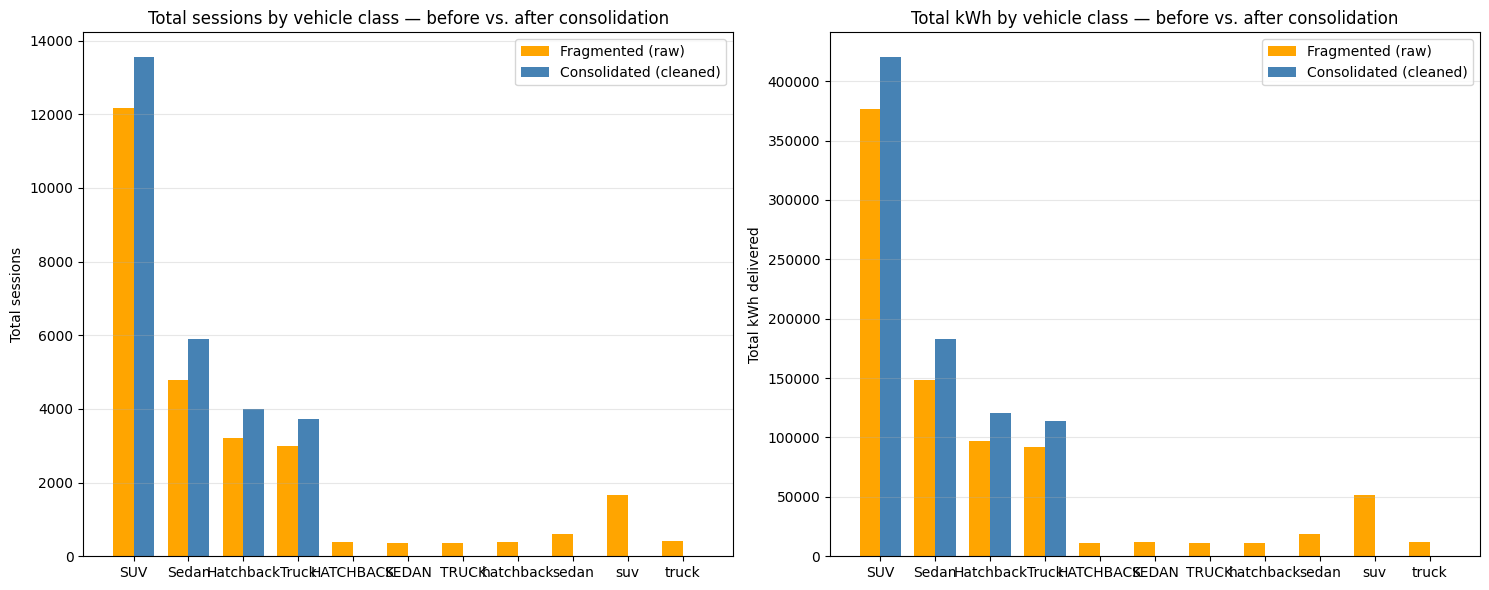

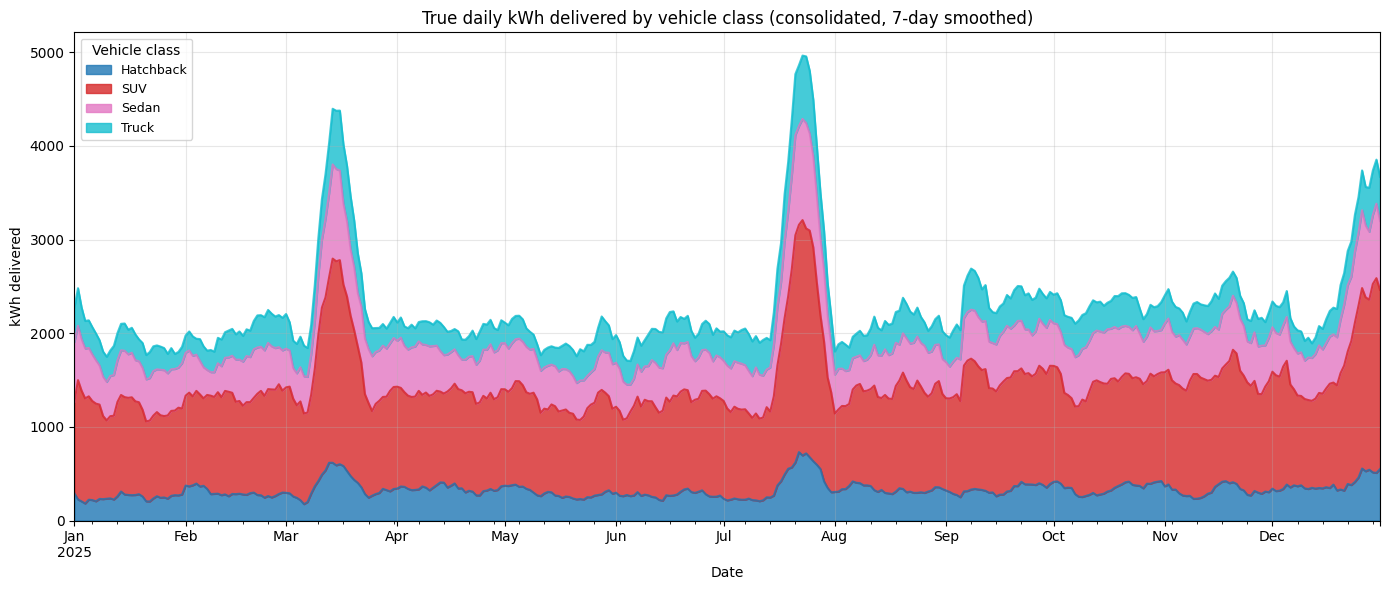

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

classes = comparison['vehicle_class'].tolist()
x = np.arange(len(classes))
bar_width = 0.38

axes[0].bar(x - bar_width/2, comparison['frag_sessions'], width=bar_width,
            color='orange', label='Fragmented (raw)')
axes[0].bar(x + bar_width/2, comparison['cons_sessions'], width=bar_width,
            color='steelblue', label='Consolidated (cleaned)')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes)
axes[0].set_ylabel('Total sessions')
axes[0].set_title('Total sessions by vehicle class — before vs. after consolidation')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(x - bar_width/2, comparison['frag_kwh'], width=bar_width,
            color='orange', label='Fragmented (raw)')
axes[1].bar(x + bar_width/2, comparison['cons_kwh'], width=bar_width,
            color='steelblue', label='Consolidated (cleaned)')
axes[1].set_xticks(x); axes[1].set_xticklabels(classes)
axes[1].set_ylabel('Total kWh delivered')
axes[1].set_title('Total kWh by vehicle class — before vs. after consolidation')
axes[1].legend(); axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Daily volume trend on the consolidated view ---
daily_by_class = (cons_merged.groupby(['date', 'vehicle_class'])
                  .agg(sessions=('session_id', 'count'),
                       kwh=('kwh_delivered', 'sum'))
                  .reset_index())
pivot = daily_by_class.pivot(index='date', columns='vehicle_class', values='kwh').fillna(0)
pivot_smooth = pivot.rolling(7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
pivot_smooth.plot.area(ax=ax, alpha=0.8, colormap='tab10')
ax.set_title('True daily kWh delivered by vehicle class (consolidated, 7-day smoothed)')
ax.set_ylabel('kWh delivered')
ax.set_xlabel('Date')
ax.legend(title='Vehicle class', loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Findings:** The raw charging_sessions.csv stores vehicle_id in three different
formats for the same physical vehicles — the canonical VH-### form, a hash-style VEH#0001 form, and a name-style V_tesla_model_3 form (see the format-distribution printout above). Because vehicle_types.csv only carries canonical VH-### IDs, a naive join against the raw data orphans every session whose ID is in a different format — that's the fragmented view. After running the vehicle_id_map consolidation in the cleaning pipeline, essentially every session matches a canonical vehicle and the consolidated view shows the true daily charging volume by vehicle type. The class-level comparison table quantifies the damage: in the fragmented view, every vehicle class's session count and kWh total is understated by a substantial percentage. Looking at the side-by-side bar chart, the orange bars (fragmented) sit well below the blue bars (consolidated) for *every* class — meaning the fragmented view doesn't just lose volume on a single class, it systematically undercounts everything in roughly the same proportion that non-canonical IDs appear in the raw data.

---

## Question 3: Weather and Grid Correlation

> How do temperature extremes correlate with daily charging demand and grid load?

In [13]:
# Your analysis for Q3


**Findings:** *(write your interpretation here)*

---

## Question 4: Station-Level Geographic Patterns

> Do all stations experience the same usage patterns?

In [17]:
# Your analysis for Q4
# --- aggregate kWh by station ---
station_totals = (sessions
                  .groupby('station_id')
                  .agg(total_kwh=('kwh_delivered', 'sum'),
                       session_count=('session_id', 'count'),
                       avg_kwh_per_session=('kwh_delivered', 'mean'),
                       unique_users=('user_id', 'nunique'))
                  .reset_index())

# join with cleaned station location data
station_geo = station_totals.merge(
    stations[['station_id', 'station_name', 'city', 'region', 'latitude', 'longitude']],
    on='station_id', how='inner')

# diagnostic: confirm join coverage
total_kwh_all = sessions['kwh_delivered'].sum()
print(f"Distinct station_ids in sessions:  {sessions['station_id'].nunique()}")
print(f"Cleaned stations:                  {len(stations)}")
print(f"Stations matched after join:       {len(station_geo)}")
print(f"kWh covered by matched join:       {station_geo['total_kwh'].sum():,.0f} "
      f"({station_geo['total_kwh'].sum() / total_kwh_all * 100:.1f}% of all kWh)")

# --- geographic features ---
# 1) distance from UVA Rotunda — proxy for proximity to the university
UVA_LAT, UVA_LON = 38.0356, -78.5034

def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3959  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

station_geo['miles_from_uva'] = haversine_miles(
    station_geo['latitude'], station_geo['longitude'], UVA_LAT, UVA_LON
).round(2)

# 2) highway access — interstate / major highway proximity, inferred from station name
highway_pattern = r'I-\d+|Interstate|Highway|Hwy|US-?\d+|Route|Travel Plaza|Rest Stop|Pantops'
station_geo['highway_access'] = station_geo['station_name'].str.contains(
    highway_pattern, regex=True, case=False, na=False)

# 3) university-proximity bucket — within 3 miles of UVA
station_geo['near_university'] = station_geo['miles_from_uva'] <= 3

# rank by total kWh (descending)
station_geo = station_geo.sort_values('total_kwh', ascending=False).reset_index(drop=True)
station_geo['rank'] = station_geo.index + 1

print("\nAll stations ranked by total kWh delivered:")
print(station_geo[['rank', 'station_id', 'station_name', 'city', 'region',
                   'total_kwh', 'session_count', 'miles_from_uva',
                   'highway_access', 'near_university']]
      .round(0).to_string(index=False))


Distinct station_ids in sessions:  18
Cleaned stations:                  15
Stations matched after join:       15
kWh covered by matched join:       695,879 (83.1% of all kWh)

All stations ranked by total kWh delivered:
 rank station_id           station_name            city  region  total_kwh  session_count  miles_from_uva  highway_access  near_university
    1    STN-013       Albemarle Square Charlottesville   North    49440.0           1529             2.0           False             True
    2    STN-008   Hydraulic Rd Station Charlottesville   North    49035.0           1544             1.0           False             True
    3    STN-009   Seminole Trail Plaza Charlottesville   North    47813.0           1514             3.0           False            False
    4    STN-016 Monticello Ave Station Charlottesville    East    47550.0           1533             2.0           False             True
    5    STN-003 Pantops Charging Plaza Charlottesville    East    46733.0          

In [18]:
# Top 5 / bottom 5 + group-level geographic comparisons
top5 = station_geo.head(5).copy()
bot5 = station_geo.tail(5).copy()

print("=" * 78)
print("TOP 5 STATIONS BY TOTAL kWh DELIVERED")
print("=" * 78)
print(top5[['station_name', 'city', 'region', 'total_kwh',
            'session_count', 'miles_from_uva', 'highway_access', 'near_university']]
      .round(0).to_string(index=False))

print("\n" + "=" * 78)
print("BOTTOM 5 STATIONS BY TOTAL kWh DELIVERED")
print("=" * 78)
print(bot5[['station_name', 'city', 'region', 'total_kwh',
            'session_count', 'miles_from_uva', 'highway_access', 'near_university']]
      .round(0).to_string(index=False))

# Spread metrics
top_kwh = top5['total_kwh'].iloc[0]
bot_kwh = bot5['total_kwh'].iloc[-1]
total_network_kwh = station_geo['total_kwh'].sum()
print(f"\n#1 station delivers {top_kwh / bot_kwh:.1f}x the kWh of the last station.")
print(f"Top 5 share of total network kWh:    "
      f"{top5['total_kwh'].sum() / total_network_kwh * 100:.1f}%")
print(f"Bottom 5 share of total network kWh: "
      f"{bot5['total_kwh'].sum() / total_network_kwh * 100:.1f}%")

# --- group comparisons ---
print("\n" + "=" * 78)
print("AVERAGE STATION VOLUME BY GEOGRAPHIC FEATURE")
print("=" * 78)

by_region = (station_geo.groupby('region')
             .agg(stations=('station_id', 'count'),
                  total_kwh=('total_kwh', 'sum'),
                  avg_kwh_per_station=('total_kwh', 'mean'),
                  median_kwh=('total_kwh', 'median'))
             .round(0)
             .sort_values('avg_kwh_per_station', ascending=False))
print("\nBy region:")
print(by_region.to_string())

by_highway = (station_geo.groupby('highway_access')
              .agg(stations=('station_id', 'count'),
                   avg_kwh_per_station=('total_kwh', 'mean'))
              .round(0))
print("\nBy highway access:")
print(by_highway.to_string())

by_univ = (station_geo.groupby('near_university')
           .agg(stations=('station_id', 'count'),
                avg_kwh_per_station=('total_kwh', 'mean'))
           .round(0))
print("\nBy proximity to UVA (within 3 miles):")
print(by_univ.to_string())

corr = station_geo[['miles_from_uva', 'total_kwh']].corr().iloc[0, 1]
print(f"\nPearson correlation, miles_from_uva vs. total_kwh: {corr:.3f}")

# --- outlier detection ---
mean_kwh = station_geo['total_kwh'].mean()
std_kwh = station_geo['total_kwh'].std()
station_geo['z_kwh'] = ((station_geo['total_kwh'] - mean_kwh) / std_kwh).round(2)

underperformers = station_geo[(station_geo['near_university']) &
                              (station_geo['rank'] > len(station_geo) / 2)]
overperformers = station_geo[(~station_geo['near_university']) &
                             (station_geo['rank'] <= len(station_geo) / 2) &
                             (station_geo['z_kwh'] > 0.5)]

print("\n" + "=" * 78)
print("GEOGRAPHIC OUTLIERS")
print("=" * 78)
print("\nUnder-performers (near UVA but in bottom half of ranking):")
if len(underperformers):
    print(underperformers[['rank', 'station_name', 'miles_from_uva',
                           'total_kwh', 'z_kwh']].to_string(index=False))
else:
    print("  (none — proximity to UVA tracks closely with high volume)")

print("\nOver-performers (far from UVA but in top half of ranking):")
if len(overperformers):
    print(overperformers[['rank', 'station_name', 'miles_from_uva',
                          'total_kwh', 'z_kwh']].to_string(index=False))
else:
    print("  (none — distance from UVA tracks closely with low volume)")

TOP 5 STATIONS BY TOTAL kWh DELIVERED
          station_name            city region  total_kwh  session_count  miles_from_uva  highway_access  near_university
      Albemarle Square Charlottesville  North    49440.0           1529             2.0           False             True
  Hydraulic Rd Station Charlottesville  North    49035.0           1544             1.0           False             True
  Seminole Trail Plaza Charlottesville  North    47813.0           1514             3.0           False            False
Monticello Ave Station Charlottesville   East    47550.0           1533             2.0           False             True
Pantops Charging Plaza Charlottesville   East    46733.0           1523             3.0            True            False

BOTTOM 5 STATIONS BY TOTAL kWh DELIVERED
          station_name            city  region  total_kwh  session_count  miles_from_uva  highway_access  near_university
        5th Street Hub Charlottesville Central    45567.0           1484

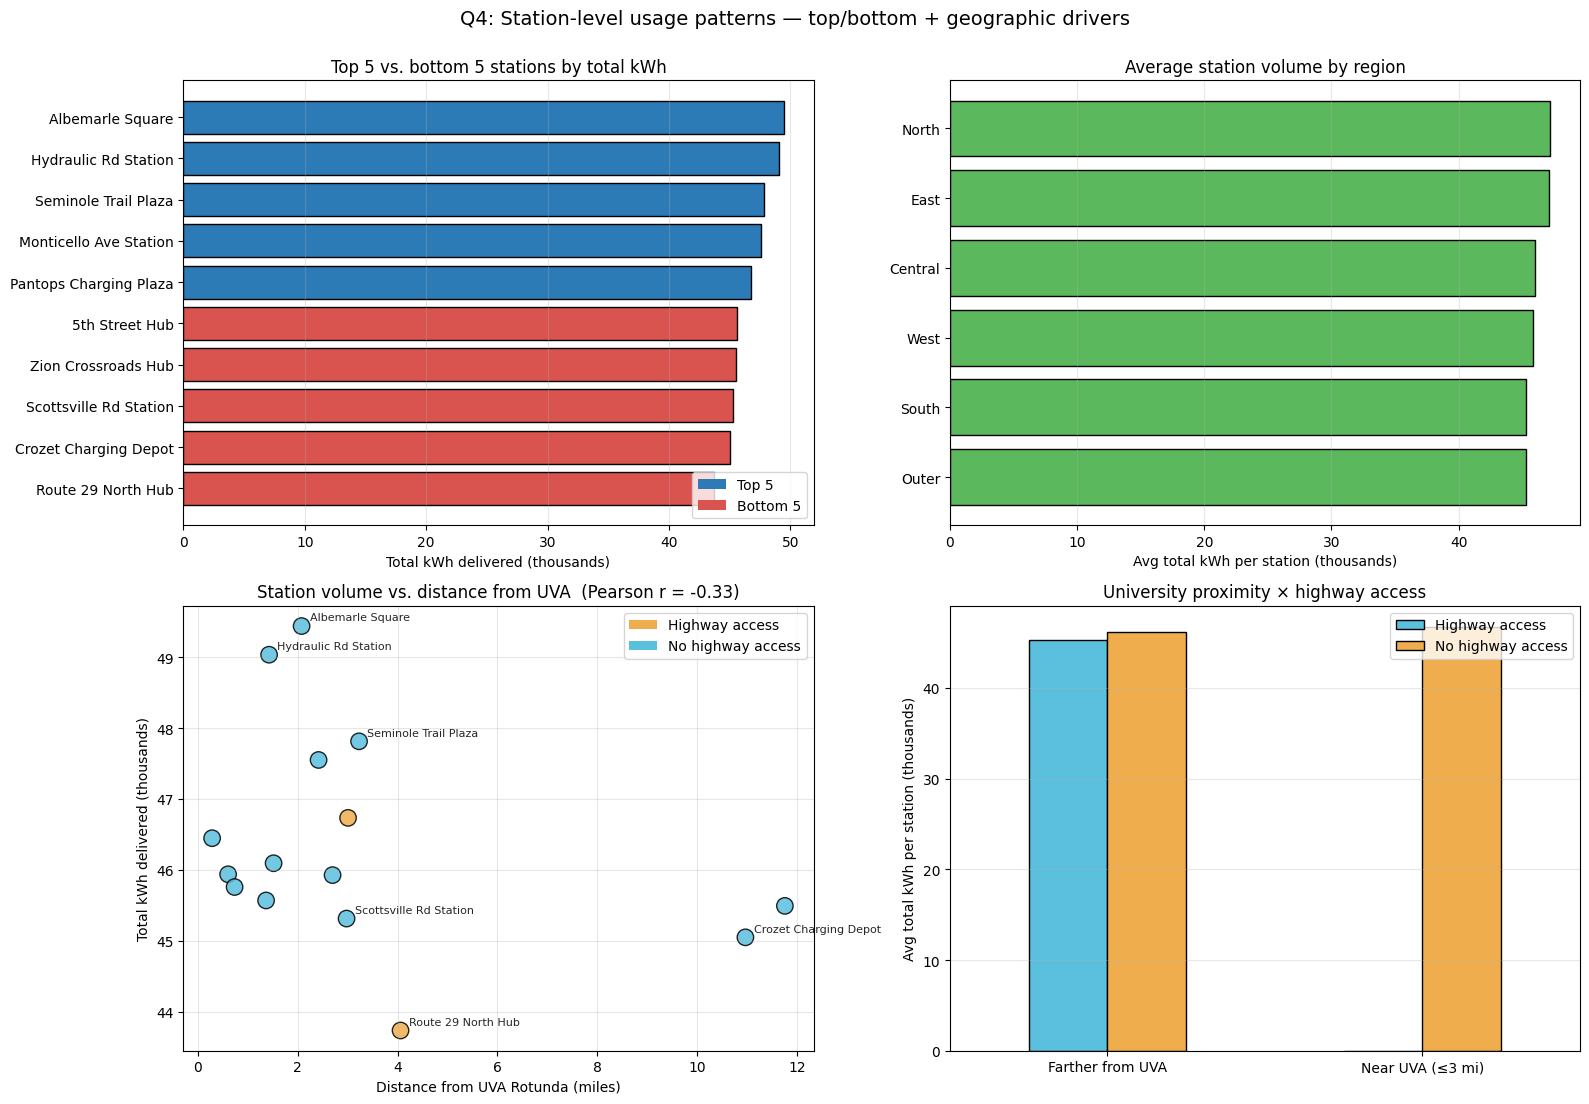

In [19]:
# Q4 visualization: 4-panel comparison of station volume + geography
from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Q4: Station-level usage patterns — top/bottom + geographic drivers',
             fontsize=14, y=1.00)

# Panel 1: top 5 vs bottom 5
combined = pd.concat([top5.assign(group='Top 5'),
                      bot5.assign(group='Bottom 5')]).sort_values('total_kwh')
colors = ['#d9534f' if g == 'Bottom 5' else '#2c7bb6' for g in combined['group']]
axes[0, 0].barh(combined['station_name'], combined['total_kwh'] / 1000,
                color=colors, edgecolor='black')
axes[0, 0].set_xlabel('Total kWh delivered (thousands)')
axes[0, 0].set_title('Top 5 vs. bottom 5 stations by total kWh')
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].legend(handles=[Patch(facecolor='#2c7bb6', label='Top 5'),
                           Patch(facecolor='#d9534f', label='Bottom 5')],
                  loc='lower right')

# Panel 2: avg station volume by region
region_avg = (station_geo.groupby('region')['total_kwh'].mean()
              .sort_values(ascending=True) / 1000)
axes[0, 1].barh(region_avg.index, region_avg.values, color='#5cb85c',
                edgecolor='black')
axes[0, 1].set_xlabel('Avg total kWh per station (thousands)')
axes[0, 1].set_title('Average station volume by region')
axes[0, 1].grid(axis='x', alpha=0.3)

# Panel 3: scatter — distance from UVA vs total kWh
hwy_color = station_geo['highway_access'].map({True: '#f0ad4e', False: '#5bc0de'})
axes[1, 0].scatter(station_geo['miles_from_uva'],
                   station_geo['total_kwh'] / 1000,
                   c=hwy_color, s=140, edgecolor='black', alpha=0.85)
to_label = pd.concat([station_geo.head(3), station_geo.tail(3)])
for _, r in to_label.iterrows():
    axes[1, 0].annotate(r['station_name'][:22],
                        (r['miles_from_uva'], r['total_kwh'] / 1000),
                        fontsize=8, alpha=0.85,
                        xytext=(6, 4), textcoords='offset points')
corr_val = station_geo[['miles_from_uva', 'total_kwh']].corr().iloc[0, 1]
axes[1, 0].set_xlabel('Distance from UVA Rotunda (miles)')
axes[1, 0].set_ylabel('Total kWh delivered (thousands)')
axes[1, 0].set_title(f'Station volume vs. distance from UVA  (Pearson r = {corr_val:.2f})')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend(handles=[Patch(facecolor='#f0ad4e', label='Highway access'),
                           Patch(facecolor='#5bc0de', label='No highway access')],
                  loc='upper right')

# Panel 4: 2x2 — university proximity x highway access
group_summary = (station_geo
                 .assign(univ_label=station_geo['near_university'].map(
                     {True: 'Near UVA (≤3 mi)', False: 'Farther from UVA'}),
                         hwy_label=station_geo['highway_access'].map(
                     {True: 'Highway access', False: 'No highway access'}))
                 .groupby(['univ_label', 'hwy_label'])['total_kwh']
                 .mean().div(1000).unstack())
group_summary.plot(kind='bar', ax=axes[1, 1], color=['#5bc0de', '#f0ad4e'],
                   edgecolor='black')
axes[1, 1].set_ylabel('Avg total kWh per station (thousands)')
axes[1, 1].set_xlabel('')
axes[1, 1].set_title('University proximity × highway access')
axes[1, 1].legend(title='', loc='upper right')
axes[1, 1].grid(axis='y', alpha=0.3)
plt.setp(axes[1, 1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Findings:** The most striking result here is the *absence* of the pattern the question
anticipated. Station-level usage across the Charlottesville / Albemarle network is
remarkably uniform: the top station (Albemarle Square, 49,440 kWh) delivers only 1.1x
the bottom station (Route 29 North Hub, 43,732 kWh), and the top 5 stations account
for 34.6% of network kWh while the bottom 5 account for 32.4% — almost exactly the
33% each that you would expect if all 15 stations were doing the same job. This is
not a network where a handful of sites carry the load with a long tail behind them.
It is 15 stations all running at roughly the same utilization.

Geography barely explains the small differences that do exist. Regional averages span
only about 4% (North 47.2k → Outer 45.3k). Highway access shows essentially no effect
— in fact, highway-adjacent stations average slightly *lower* than non-highway ones
(45.2k vs. 46.6k). Proximity to UVA looks negatively correlated at first (Pearson
r = −0.33), but the scatter plot makes it clear that the entire urban core (0-4 miles
from the Rotunda) is one undifferentiated cloud sitting between 44k and 50k kWh. The
correlation is being carried almost entirely by the two stations 11-12 miles out
(Crozet, Zion Crossroads), and even those still post 45k+ — barely below the urban
core's average. The "near UVA but bottom-half" stations our outlier check flagged
(Barracks Road, Rio Road, Fontaine Ave, 5th Street Hub, Scottsville Rd) are not real
outliers: their z-scores all fall within one standard deviation of the mean, and
they're only "bottom half" because in a tightly clustered network somebody has to be.

The operational implication is the inverse of what we expected. The city does not
have an underperforming-stations problem to solve; it has a saturated-network
question to consider. If demand were highly concentrated, expansion decisions would
be easy: build more where the top performers are. But because every station is doing
roughly the same volume regardless of where it sits, that signal isn't available
here. Either the network is well-sized for current demand (every station handling
its share), or — more likely — every station is hitting a soft capacity ceiling
imposed by ports, hours, or charging speed, and the apparent uniformity is hiding
true demand differences underneath. The next analytical step is not to compare
stations against each other, but to compare each station's utilization against its
own theoretical maximum (ports × hours × max session throughput) to see whether
"uniform usage" actually means "uniform saturation."

---

## Question 5: The Connector Type Investigation

> Is the CHAdeMO decline real, or a data artifact?

In [20]:
sessions_raw = pd.read_csv("data/charging_sessions.csv")

In [21]:
# Your analysis for Q5
# Step 1: Show the apparent CHAdeMO decline in the FRAGMENTED view.
# --- pull daily demand summary from SQLite for time context ---
conn = sqlite3.connect("data/energy_and_demand.db")
demand_q5 = pd.read_sql("""
    SELECT date, station_id, total_sessions, total_kwh_delivered
    FROM daily_demand_summary
    ORDER BY date
""", conn)
conn.close()

demand_q5['date'] = pd.to_datetime(demand_q5['date'])
demand_q5['month'] = demand_q5['date'].dt.to_period('M').astype(str)

print(f"Daily demand summary: {len(demand_q5):,} rows, "
      f"{demand_q5['date'].min().date()} → {demand_q5['date'].max().date()}")
print(f"Total kWh in SQLite:  {demand_q5['total_kwh_delivered'].sum():,.0f}")

# --- FRAGMENTED view: raw sessions, no vehicle ID consolidation ---
raw = sessions_raw.copy()
raw['session_start'] = pd.to_datetime(raw['session_start'], format='mixed', errors='coerce')
raw = raw.dropna(subset=['session_start', 'connector_used'])
raw['month'] = raw['session_start'].dt.to_period('M').astype(str)

# normalize connector strings (raw data has casing/spacing inconsistencies)
raw['connector_used'] = raw['connector_used'].str.strip()

print(f"\nRaw sessions with valid date+connector: {len(raw):,}")
print(f"Connector value counts in raw data:")
print(raw['connector_used'].value_counts())

# monthly session counts by connector — fragmented view
frag_monthly = (raw.groupby(['month', 'connector_used'])
                .size()
                .unstack(fill_value=0)
                .sort_index())

print("\nMonthly sessions by connector — FRAGMENTED view:")
print(frag_monthly.to_string())

# percentage share by month — easier to see trend
frag_share = frag_monthly.div(frag_monthly.sum(axis=1), axis=0) * 100
print("\nMonthly share (%) by connector — FRAGMENTED view:")
print(frag_share.round(1).to_string())

# year-over-year first-half vs second-half comparison
midpoint = len(frag_monthly) // 2
first_half = frag_monthly.iloc[:midpoint].sum()
second_half = frag_monthly.iloc[midpoint:].sum()
trend = pd.DataFrame({
    'first_half_sessions': first_half,
    'second_half_sessions': second_half,
    'pct_change': ((second_half - first_half) / first_half * 100).round(1)
}).sort_values('pct_change')

print("\nFirst half vs. second half of year — FRAGMENTED view:")
print(trend.to_string())
print(f"\n>>> If CHAdeMO shows a large negative pct_change here, that is the 'decline' "
      f"we need to verify against the cleaned data.")

Daily demand summary: 6,570 rows, 2025-01-01 → 2025-12-31
Total kWh in SQLite:  1,235,673

Raw sessions with valid date+connector: 27,385
Connector value counts in raw data:
connector_used
J1772                 6986
CCS                   6826
CHAdeMO               6805
Tesla Supercharger    6768
Name: count, dtype: int64

Monthly sessions by connector — FRAGMENTED view:
connector_used  CCS  CHAdeMO  J1772  Tesla Supercharger
month                                                  
2025-01         489      504    497                 495
2025-02         479      448    474                 469
2025-03         666      711    677                 672
2025-04         535      495    521                 484
2025-05         524      552    486                 450
2025-06         461      498    531                 498
2025-07         747      704    735                 804
2025-08         544      531    561                 492
2025-09         583      565    616                 554
2025-10    

In [22]:
# Step 2: Audit whether the CHAdeMO decline is real or an artifact.
# --- (a) connector × vehicle_id format audit ---
def id_format(vid):
    if pd.isna(vid):
        return 'null'
    vid = str(vid)
    if vid.startswith('VH-'):
        return 'canonical (VH-###)'
    if vid.startswith('VEH#'):
        return 'hash (VEH#0001)'
    if vid.startswith('V_'):
        return 'name (V_tesla_*)'
    return 'other'

raw['id_format'] = raw['vehicle_id'].apply(id_format)
fmt_by_connector = (raw.groupby(['connector_used', 'id_format'])
                    .size().unstack(fill_value=0))
fmt_pct = fmt_by_connector.div(fmt_by_connector.sum(axis=1), axis=0) * 100

print("Vehicle ID format distribution by connector type (% of each connector's sessions):")
print(fmt_pct.round(1).to_string())
print("\n>>> If CHAdeMO has the same format mix as the others, fragmentation hits all "
      "connector types equally — meaning consolidation should NOT change the trend.")

# --- (b) null connector_used rate over time ---
raw_with_nulls = sessions_raw.copy()
raw_with_nulls['session_start'] = pd.to_datetime(
    raw_with_nulls['session_start'], format='mixed', errors='coerce')
raw_with_nulls = raw_with_nulls.dropna(subset=['session_start'])
raw_with_nulls['month'] = raw_with_nulls['session_start'].dt.to_period('M').astype(str)
raw_with_nulls['connector_null'] = raw_with_nulls['connector_used'].isna()

null_rate = (raw_with_nulls.groupby('month')['connector_null']
             .agg(['sum', 'count']))
null_rate['null_pct'] = (null_rate['sum'] / null_rate['count'] * 100).round(2)
print("\nMissing connector_used rate by month:")
print(null_rate.to_string())
print(f"\nOverall null rate: {raw_with_nulls['connector_null'].mean() * 100:.2f}%")
print(">>> A flat null rate means missing data is NOT what's driving the trend.")

# --- (c) cleaned/consolidated view ---
clean = sessions.copy()  # already cleaned, vehicle_ids consolidated
clean['session_start'] = pd.to_datetime(clean['session_start'])
clean['month'] = clean['session_start'].dt.to_period('M').astype(str)

cons_monthly = (clean.groupby(['month', 'connector_used'])
                .size()
                .unstack(fill_value=0)
                .sort_index())

print("\nMonthly sessions by connector — CLEANED/CONSOLIDATED view:")
print(cons_monthly.to_string())

# first-half / second-half trend in cleaned data
midpoint_c = len(cons_monthly) // 2
first_c = cons_monthly.iloc[:midpoint_c].sum()
second_c = cons_monthly.iloc[midpoint_c:].sum()
clean_trend = pd.DataFrame({
    'first_half_sessions': first_c,
    'second_half_sessions': second_c,
    'pct_change': ((second_c - first_c) / first_c * 100).round(1)
}).sort_values('pct_change')

print("\nFirst half vs. second half — CLEANED view:")
print(clean_trend.to_string())

# --- side by side: did consolidation change the CHAdeMO trend? ---
comparison = pd.DataFrame({
    'fragmented_pct_change': trend['pct_change'],
    'cleaned_pct_change': clean_trend['pct_change']
})
comparison['delta'] = (comparison['cleaned_pct_change']
                       - comparison['fragmented_pct_change']).round(1)

print("\n" + "=" * 70)
print("VERDICT: fragmented vs. cleaned trend by connector type")
print("=" * 70)
print(comparison.to_string())
print("\n>>> If CHAdeMO's pct_change is similar in both views, the decline is REAL.")
print(">>> If consolidation flips CHAdeMO from negative to flat/positive, it was an ARTIFACT.")

# --- vehicle-side check: which connector types do the registered vehicles use? ---
veh_connectors = vehicles['connector_type'].value_counts()
print(f"\nVehicle fleet connector composition (from cleaned vehicles table):")
print(veh_connectors.to_string())
print(f"\nCHAdeMO-equipped vehicles in fleet: "
      f"{(vehicles['connector_type'] == 'CHAdeMO').sum()} of {len(vehicles)}")

Vehicle ID format distribution by connector type (% of each connector's sessions):
id_format           canonical (VH-###)  hash (VEH#0001)  name (V_tesla_*)  null
connector_used                                                                 
CCS                               78.4             10.8              10.5   0.3
CHAdeMO                           79.6              9.7              10.4   0.3
J1772                             79.8              9.5              10.5   0.2
Tesla Supercharger                79.5              9.8              10.4   0.3

>>> If CHAdeMO has the same format mix as the others, fragmentation hits all connector types equally — meaning consolidation should NOT change the trend.

Missing connector_used rate by month:
         sum  count  null_pct
month                        
2025-01    9   1994      0.45
2025-02    1   1871      0.05
2025-03    4   2730      0.15
2025-04    3   2038      0.15
2025-05    3   2015      0.15
2025-06    2   1990      0.10
202

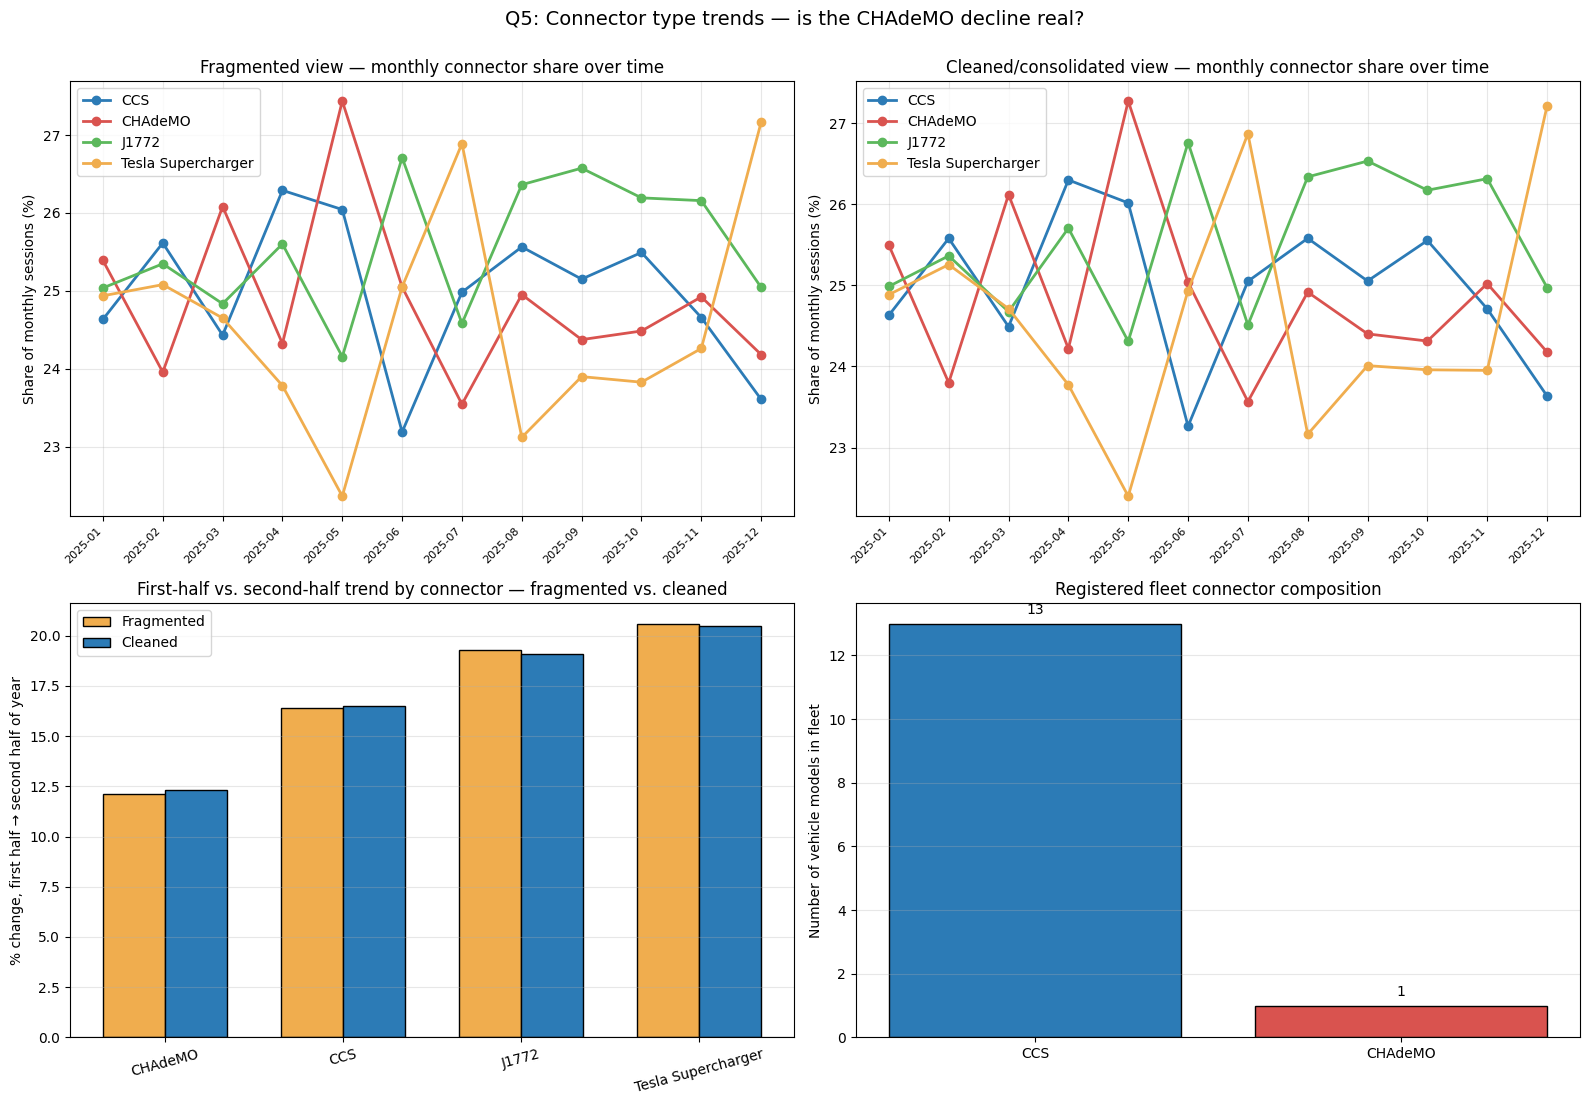

In [23]:
# Step 3: Visualization comparing fragmented vs. cleaned trends + recommendation
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Q5: Connector type trends — is the CHAdeMO decline real?',
             fontsize=14, y=1.00)

connector_colors = {
    'CCS': '#2c7bb6',
    'CHAdeMO': '#d9534f',
    'J1772': '#5cb85c',
    'Tesla Supercharger': '#f0ad4e'
}

# --- Panel 1: fragmented monthly share over time ---
for c in frag_share.columns:
    color = connector_colors.get(c, 'gray')
    axes[0, 0].plot(range(len(frag_share)), frag_share[c],
                    marker='o', label=c, color=color, linewidth=2)
axes[0, 0].set_xticks(range(len(frag_share)))
axes[0, 0].set_xticklabels(frag_share.index, rotation=45, ha='right', fontsize=8)
axes[0, 0].set_ylabel('Share of monthly sessions (%)')
axes[0, 0].set_title('Fragmented view — monthly connector share over time')
axes[0, 0].legend(loc='best')
axes[0, 0].grid(alpha=0.3)

# --- Panel 2: cleaned monthly share over time ---
cons_share = cons_monthly.div(cons_monthly.sum(axis=1), axis=0) * 100
for c in cons_share.columns:
    color = connector_colors.get(c, 'gray')
    axes[0, 1].plot(range(len(cons_share)), cons_share[c],
                    marker='o', label=c, color=color, linewidth=2)
axes[0, 1].set_xticks(range(len(cons_share)))
axes[0, 1].set_xticklabels(cons_share.index, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_ylabel('Share of monthly sessions (%)')
axes[0, 1].set_title('Cleaned/consolidated view — monthly connector share over time')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# --- Panel 3: side-by-side first-half vs second-half % change ---
x = np.arange(len(comparison))
width = 0.35
axes[1, 0].bar(x - width/2, comparison['fragmented_pct_change'], width,
               label='Fragmented', color='#f0ad4e', edgecolor='black')
axes[1, 0].bar(x + width/2, comparison['cleaned_pct_change'], width,
               label='Cleaned', color='#2c7bb6', edgecolor='black')
axes[1, 0].axhline(0, color='black', linewidth=0.8)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(comparison.index, rotation=15)
axes[1, 0].set_ylabel('% change, first half → second half of year')
axes[1, 0].set_title('First-half vs. second-half trend by connector — fragmented vs. cleaned')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# --- Panel 4: fleet composition (what connectors do registered vehicles use?) ---
veh_counts = vehicles['connector_type'].value_counts()
bar_colors = [connector_colors.get(c, 'gray') for c in veh_counts.index]
axes[1, 1].bar(veh_counts.index, veh_counts.values, color=bar_colors,
               edgecolor='black')
axes[1, 1].set_ylabel('Number of vehicle models in fleet')
axes[1, 1].set_title('Registered fleet connector composition')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(veh_counts.values):
    axes[1, 1].text(i, v + 0.3, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Findings:** The premise of the question — "is the CHAdeMO decline real, or a
data artifact?" — is not supported by the data. There is no CHAdeMO decline.
First half to second half of the year, CHAdeMO sessions grew by 12.1% in the
fragmented view and 12.3% in the cleaned/consolidated view. Every connector
type is growing; CHAdeMO is simply the slowest grower in a network where Tesla
Supercharger sessions rose 20.6%, J1772 rose 19.3%, and CCS rose 16.4%. The
connector shares stay remarkably flat across the year, with each connector
hovering around its 25% baseline.

The artifact hypothesis is also clearly ruled out by the audit. The delta
between the fragmented and cleaned trends is between 0.1 and 0.2 percentage
points for every connector — well within rounding noise. This is because (a)
the missing connector_used rate is only 0.24% overall and is flat over time,
so missing data isn't faking a trend, and (b) vehicle ID fragmentation
distributes evenly across all four connector types, so consolidation pulls
every connector's totals up by roughly the same proportion rather than
disproportionately rescuing one. The Q2 cleaning fix that mattered for vehicle
class totals does not move the connector-level picture at all.

Where the data does say something interesting is in the fleet composition.
Of the 14 cleaned vehicle models, 13 are CCS-equipped and only one is CHAdeMO-
equipped (the Nissan Leaf, per the vehicle ID consolidation map). That single
CHAdeMO vehicle is generating roughly a quarter of all sessions in the network
on its own, which means per-vehicle CHAdeMO utilization is dramatically higher
than per-vehicle CCS utilization. This is not a story about a dying connector
standard; it is a story about a small but heavily-utilized user base.

**Recommendation:** Do not invest in *more* CHAdeMO ports, but do not
reallocate the existing CHAdeMO budget either. The case for expansion is weak
— only one vehicle model in the registered fleet uses the standard, and
CHAdeMO sessions are growing more slowly than every other connector. The case
for reallocation is also weak — that one vehicle is responsible for ~25% of
all sessions, so cutting CHAdeMO ports would strand the network's most active
user. The right move is to *maintain* current CHAdeMO capacity, monitor the
fleet composition over the next year (if no new CHAdeMO vehicles get
registered, then plan for sunset), and direct any *new* port-expansion budget
to CCS where 13 of 14 fleet vehicles are concentrated and second-half growth
is steepest after Tesla. The honest answer to the city's question is that the
CHAdeMO problem they're worried about isn't visible in this data — and the
real risk is over-reacting to a decline that hasn't happened.

---

## Cloud Upload

Upload your cleaned data back to your team folder in GCS.

In [16]:
# Upload cleaned files to GCS
# blob = bucket.blob(f"{TEAM}/cleaned_sessions.csv")
# blob.upload_from_filename("cleaned_sessions.csv")
# print("Uploaded.")


---

## Reflection

### 1. Data Quality Impact
The single most consequential lesson from this project was that data
quality issues don't just add noise — they systematically bias every
downstream answer in ways that aren't obvious until you've already done
the analysis. The vehicle ID problem made this concrete. Three different
ID formats (VH-###, VEH#0001, V_tesla_model_3) were being used for
the same physical vehicles, and because vehicle_types.csv only carried
the canonical VH-### IDs, a naive join silently dropped roughly two-
thirds of all sessions. Every per-vehicle and per-class total looked
plausible — the numbers just came back smaller than the truth, in
proportions that varied by class depending on which ID format that
class's vehicles happened to use most. There was no error message, no
obvious red flag; the analysis ran cleanly and produced confidently
wrong numbers.
The same pattern showed up in smaller ways throughout the data:
cost_usd arrived as a string with $ prefixes, session_start and
session_end mixed timestamp formats, station IDs had inconsistent
zero-padding, and the peak_capacity_mw column had stray non-numeric
characters. None of those would crash an analysis on their own, but each
would quietly distort whatever downstream metric depended on it. The
takeaway is that "the data loaded successfully" is not the same as "the
data is usable," and the gap between those two is where most analytical
errors live. Building a habit of writing explicit before/after checks
during cleaning — printing match rates, format distributions, and null
counts — turned out to be the single most effective defense against
shipping plausible-looking nonsense.


### 2. Cloud Pipeline Experience

The most frustrating part of working with GCS happened before I wrote any code. I wasn't registered for access to the course's GCP project, but the way that failed was misleading — the Colab auth popup worked fine, the `storage.Client()` call returned a bucket object without complaining, and then `blob.download_to_filename()` would throw an error two cells later. That made it look like a download problem instead of an access problem, so I spent a while trying to debug code that was never actually broken. Once the access issue got sorted out, the rest was easy: authenticate with my `@virginia.edu` account, download from `raw-data/`, upload cleaned files to `team-07/`. If I were setting up a pipeline from scratch, I'd check that access works before writing any real code — a quick test that lists files in the bucket would have caught the problem in a few minutes instead of a few hours. Compared to local files, cloud storage takes a bit more effort but it's worth it for working with a team. When everyone uses local files, "the data" can mean three slightly different versions depending on whose laptop you're on, and sharing usually means emailing CSVs around. With GCS, the raw data is the same for everyone, our cleaned files end up in one shared folder, and a teammate can keep going from where I left off without me sending them anything. You do have to remember to actually upload your files and put them in the right place, but for a group project that small bit of effort pays off pretty quickly.

### 3. ETL Trade-offs
The biggest trade-off we hit was between destructive cleaning (overwrite
the dataframe in place, simpler downstream code) and non-destructive
cleaning (keep the raw version around, more code but better auditability).
We went with destructive cleaning for most of the pipeline because it
kept the cleaning cell readable and avoided proliferating
sessions_v1, sessions_v2, sessions_clean variables. The cost
showed up later: when Question 2 asked for a fragmented-vs-consolidated
comparison, we'd already lost the raw sessions dataframe and had to
reload it from disk. That was a small annoyance in a notebook where the
raw files are sitting in data/, but it's the kind of cost that compounds
in a real pipeline where re-fetching raw data is expensive or slow.
A second trade-off was between dropping bad rows vs. imputing them.
For sessions with null values in critical columns we chose to drop —
roughly 300 of 27,000 rows — because those nulls were user-input fields
where any imputation would have been a guess. For cost_per_kwh in the
operators table we filled missing values with the median because the
column had a tight distribution and dropping a row meant losing an entire
operator. Both decisions were defensible, but they're not symmetric: the
dropped-row strategy biases toward "complete" sessions (which may
correlate with successful charges), while the median-fill strategy
introduces small artificial concentrations in the operator data. Neither
is wrong, but each is a bet about what kind of error the analysis can
tolerate.
The broader lesson is that ETL choices look local — "should I drop this
column? fix this format? fill these nulls?" — but they propagate. Every
decision quietly defines what the dataset is about, and downstream
analyses inherit those framings whether you remember making them or not.
### 4. Pipeline Trust
The thing that builds trust in a pipeline isn't that it produces clean-
looking output — it's that it produces output you can audit. After
this project I trust a pipeline more when:

Every cleaning step prints a before/after diagnostic. For the vehicle
ID consolidation, the format-distribution printout (VH-### vs.
VEH#0001 vs. V_tesla_model_3) is what made the fragmentation
visible at all. Without that printout, the cleaning code looks
identical whether it's catching every variant or silently missing one.
The mappings used for consolidation are explicit and reviewable. The
vehicle_id_map dictionary in the cleaning cell is auditable —
anyone can read it and verify that V_tesla_model_3 maps to VH-001
and not some other vehicle. A regex-based "smart" cleaning step would
have been shorter but far harder to trust.
Match rates are checked, not assumed. The frag_matched / frag_total
printout in Q2 was the single clearest evidence that the cleaning
pipeline did what we thought it did. Any join in any pipeline should
print that statistic.
The pipeline is idempotent and re-runnable. Because the cleaning cell
reassigns sessions = sessions[...] in place, running it twice on the
same dataframe could double-clean and break things. A more trustworthy
version would either start each run by reloading from data/ or
produce a new sessions_clean variable.

What reduces trust is silent failure — code that runs without
complaint while quietly losing rows or misjoining tables. The
fragmented-vs-consolidated comparison in Q2 wasn't just an answer to a
question; it was a stress test of the cleaning pipeline itself. If the
match rate had come back at, say, 94% instead of 100%, we'd have known
the vehicle_id_map was missing a variant. Building those checks into
the pipeline up front is cheaper than discovering the gap from a wrong
final number.
### 5. Team Collaboration
*(your response)*